# Task 1: Exploratory Spatial Data Analysis
Comparing LLM-generated point datasets vs RADIAN datasets for London and Berlin.

Includes full grid visualizations (Models x Tasks) overlaid on city boundaries, plus exploratory spatial statistics.

> **Note on Data Provenance**: This analysis uses the data located in `geoai_paddeaux/llm-outputs/`. While the original data collector classified outputs into failed/flagged/validated, fixed several of the LLM GeoJSON files were manually fixed (e.g. closing parentheses, removing trailing, etc.) that originally failed parsing during the automated collection phase, meaning the `validated` folders here contain a more complete set than the original raw collection outputs.

In [109]:
import geopandas as gpd
import contextily as cx
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pointpats import PointPattern, centrography
from pointpats.quadrat_statistics import QStatistic
import numpy as np
import os
from scipy.spatial import cKDTree
import warnings
warnings.filterwarnings('ignore') # Suppress centroid warning for geographic CRS

# Set up paths relative to the geoai_paddeaux repo root
BASE_DIR = 'llm-outputs'
MODELS = ['claude', 'gemini', 'gpt4.1', 'gpt5.4', 'gpt-oss-120b', 'gpt-oss-20b', 'llama', 'radian']
TASKS = ['taskA', 'taskB', 'taskC']
CITIES = ['london', 'berlin']

def get_file_path(model, task, city):
    return os.path.join(BASE_DIR, model, 'validated', f'{task}_{city}_{model}.geojson')

def get_utm_crs(city):
    # EPSG:32631 for London, EPSG:32633 for Berlin for accurate distance/area calculations
    return 'epsg:32631' if city == 'london' else 'epsg:32633'

print("Libraries loaded and paths set.")

Libraries loaded and paths set.


### Descriptive Spatial Statistics

To establish a baseline evaluation of the LLM-generated point patterns, we computed a suite of descriptive spatial statistics for each model across tasks and target cities. These metrics are categorized into three areas: Prompt Adherence, Spatial Distribution, and Centrography.

##### Prompt Adherence & Data Quality

- **Adherence Score:** A composite score (out of 6 for Task A, and 7 for Tasks B and C) measuring strict compliance with the prompt's structural and semantic constraints. Points were awarded for generating a valid GeoJSON FeatureCollection, producing exactly 500 point geometries, ensuring valid WGS84 coordinate bounds, achieving 100% boundary containment, and including the correct schema attributes (e.g., the name key).
- **OSM Grounding (%):** Computed exclusively for Task B to quantify real-world data retrieval accuracy. We extracted the complete ground-truth database of restaurant names for each city using the Overpass API. We then calculated the percentage of LLM-generated names that matched the real-world database, utilizing fuzzy string matching ($\ge 85%$ similarity threshold) to account for minor spelling or formatting variations.
- **Unique Names:** The total count of distinct restaurant names generated, utilized to detect semantic hallucination loops (e.g., generating "McDonald's" 500 times) and measure dataset diversity.

##### Spatial Distribution & Density
- **Points ($n$) & Density** (pts/km²): The total count of valid point features generated and their subsequent density relative to the true area of the bounding polygon.
- **Within Boundary** (%): The exact percentage of generated points successfully confined within the provided geographic boundary constraint.
- **Nearest Neighbor Index** (NNI): Evaluated to assess micro-level clustering. NNI represents the ratio of the observed mean distance between nearest neighbors to the expected mean distance under Complete Spatial Randomness (CSR).
- **Variance-Mean Ratio** (VMR): Computed via Quadrat Analysis to test for macro-level Complete Spatial Randomness. The bounding area is divided into a uniform grid, and the variance of point counts per quadrat is divided by the mean.
    - $\text{VMR} \approx 1$ indicates CSR (a random, independent spatial distribution).
    - $\text{VMR} > 1$ indicates spatial clustering.
    - $\text{VMR} < 1$ indicates spatial dispersion or uniformity.

##### Centrography
- **Standard Distance** (km): A measure of the absolute spatial dispersion of the generated points around their center, functioning as a two-dimensional equivalent to standard deviation.
- **Mean Center** (UTM): The average $x$ and $y$ projected coordinates of all points. This was utilized to detect spatial anchoring, determining whether the LLMs systematically skewed their generations toward a specific geographic centroid (e.g., the exact geographic center of London).

In [ ]:
def calc_nni(gdf, boundary_area):
    """Calculate Nearest Neighbor Index (Observed Mean Dist / Expected Mean Dist)"""
    if len(gdf) < 2: return np.nan
    coords = np.array(list(zip(gdf.geometry.x, gdf.geometry.y)))
    tree = cKDTree(coords)
    dists, _ = tree.query(coords, k=2)
    mean_obs = np.mean(dists[:, 1])
    density = len(gdf) / boundary_area
    mean_exp = 0.5 / np.sqrt(density)
    return mean_obs / mean_exp

def compute_descriptive_stats(task, city):
    boundary_path = f'{city}_4326.geojson'
    if not os.path.exists(boundary_path):
        return pd.DataFrame()
        
    # Load and project boundary for accurate geometry
    boundary = gpd.read_file(boundary_path)
    utm_crs = get_utm_crs(city)
    boundary_utm = boundary.to_crs(utm_crs)
    boundary_geom = boundary_utm.geometry.iloc[0]
    boundary_area_m2 = boundary_geom.area
    boundary_area_km2 = boundary_area_m2 / 1e6
    
    # Load OSM names if task == 'taskB'
    import json
    osm_names = set()
    if task == 'taskB':
        osm_path = f'{city}_osm_names.json'
        if os.path.exists(osm_path):
            with open(osm_path, 'r') as f:
                osm_names = set(json.load(f))
                
    results = []
    for model in MODELS:
        filepath = get_file_path(model, task, city)
        if not os.path.exists(filepath):
            continue
            
        try:
            gdf = gpd.read_file(filepath)
            if gdf.empty:
                continue
        except Exception:
            continue
            
        # Project to UTM and ensure all geometries are pure Points
        gdf_utm = gdf.to_crs(utm_crs)
        gdf_utm['geometry'] = gdf_utm.geometry.centroid
        
        # 1. Pct Within Geometry
        within = gdf_utm[gdf_utm.within(boundary_geom)]
        pct_within = (len(within) / len(gdf_utm)) * 100
        
        # 2. Centrography
        coords = np.array(list(zip(gdf_utm.geometry.x, gdf_utm.geometry.y)))
        mc = centrography.mean_center(coords)
        sd = centrography.std_distance(coords)
        
        # 3. Nearest Neighbor Index (NNI)
        nni = calc_nni(gdf_utm, boundary_area_m2)
        
        # 4. Quadrat Analysis (VMR)
        try:
            q = QStatistic(coords, nx=10, ny=10)
            vmr = q.chi2 / (100 - 1)
        except Exception:
            vmr = np.nan
            
        # --- ADHERENCE SCORE LOGIC ---
        score = 0
        max_score = 7 if task in ['taskB', 'taskC'] else 6
        
        # Req 1: FeatureCollection (implicit if loaded)
        score += 1
        # Req 2: Exactly 500 Points
        if len(gdf) == 500 and all(gdf.geom_type == 'Point'):
            score += 1
        # Req 3/4/5 (Depends on task)
        if task == 'taskC':
            if 'id' in gdf.columns:
                score += 1
        else:
            if 'name' in gdf.columns and not gdf['name'].isnull().all():
                score += 1
                
        # Req: Within Boundary
        if pct_within == 100.0:
            score += 1
            
        # Req: Valid WGS84
        bounds = gdf.total_bounds
        if bounds[0] >= -180 and bounds[2] <= 180 and bounds[1] >= -90 and bounds[3] <= 90:
            score += 1
            
        # Req: Only GeoJSON (Assume True for now as validated files are clean)
        score += 1
        
        osm_match_pct = None
        if task == 'taskB':
            if 'name' in gdf.columns and len(osm_names) > 0:
                from thefuzz import fuzz
                matches = 0
                for name in gdf['name'].dropna():
                    name_lower = str(name).lower().strip()
                    if name_lower in osm_names:
                        matches += 1
                    else:
                        for true_name in osm_names:
                            if fuzz.ratio(name_lower, true_name) > 85:
                                matches += 1
                                break
                osm_match_pct = (matches / len(gdf)) * 100
                if osm_match_pct >= 50.0:
                    score += 1
                unique_name = len(gdf['name'].unique())
        elif task == 'taskC':
            if pd.notnull(vmr) and 0.8 <= vmr <= 1.2:
                score += 1
        
        res = {
            'Model': model.upper(),
            'Adherence': f"{score}/{max_score}",
            'Points (n)': len(gdf),
            'Density (pts/km²)': round(len(gdf) / boundary_area_km2, 2),
            'Within Boundary (%)': round(pct_within, 1),
            'NNI': round(nni, 3) if pd.notnull(nni) else None,
            'Quadrat VMR': round(vmr, 3) if pd.notnull(vmr) else None,
            'Std Distance (km)': round(sd / 1000, 2),
            'Mean Center (UTM)': f'({int(mc[0])}, {int(mc[1])})'
        }
        
        if task == 'taskB':
            res['OSM Grounding (%)'] = round(osm_match_pct, 1) if osm_match_pct is not None else None
            res['Unique Names'] = unique_name if unique_name is not None else None
            
        results.append(res)
        
    df = pd.DataFrame(results)
    return df


In [89]:
# Descriptive STatistics - Task A
stats_taskA_london = compute_descriptive_stats('taskA', 'london')
print('Descriptive Statistics - Task A - London')
display(stats_taskA_london)

stats_taskA_berlin = compute_descriptive_stats('taskA', 'berlin')
print('Descriptive Statistics - Task A - Berlin')
display(stats_taskA_berlin)

Descriptive Statistics - Task A - London


,Model,Adherence,Points (n),Density (pts/km²),Within Boundary (%),NNI,Quadrat VMR,Std Distance (km),Mean Center (UTM)
0,CLAUDE,5/6,552,0.35,100.0,0.220,34.078,4.67,"(282524, 5711498)"
1,GEMINI,6/6,500,0.31,100.0,0.778,0.182,7.17,"(286213, 5709485)"
2,GPT4.1,5/6,500,0.31,52.4,0.574,80.614,39.87,"(262616, 5734970)"
3,GPT5.4,5/6,500,0.31,92.8,1.316,1.212,13.99,"(287798, 5710652)"
4,GPT-OSS-120B,6/6,500,0.31,100.0,0.000,NaN,NaN,"(282950, 5710891)"
5,LLAMA,5/6,498,0.31,100.0,0.000,495.984,0.00,"(282952, 5710896)"
6,RADIAN,5/6,500,0.31,100.0,0.742,15.511,10.69,"(281041, 5709771)"


Descriptive Statistics - Task A - Berlin


,Model,Adherence,Points (n),Density (pts/km²),Within Boundary (%),NNI,Quadrat VMR,Std Distance (km),Mean Center (UTM)
0,CLAUDE,4/6,574,0.64,99.5,0.330,80.969,4.89,"(390726, 5819080)"
1,GEMINI,6/6,500,0.56,100.0,0.834,0.202,5.60,"(394469, 5818902)"
2,GPT4.1,5/6,500,0.56,7.4,2.184,8.885,118.29,"(397316, 6009615)"
3,GPT5.4,5/6,500,0.56,65.8,1.843,0.554,14.91,"(394100, 5820559)"
4,GPT-OSS-120B,6/6,500,0.56,100.0,0.500,0.198,4.36,"(391140, 5818808)"
5,GPT-OSS-20B,5/6,500,0.56,93.0,0.849,0.194,5.30,"(391267, 5812295)"
6,LLAMA,5/6,509,0.57,100.0,0.000,NaN,NaN,"(391103, 5819796)"
7,RADIAN,5/6,500,0.56,100.0,0.889,8.764,9.26,"(393272, 5819350)"


In [92]:
# Descriptive STatistics - Task B
stats_taskB_london = compute_descriptive_stats('taskB', 'london')
print('Descriptive Statistics - Task B - London')
display(stats_taskB_london)

stats_taskB_berlin = compute_descriptive_stats('taskB', 'berlin')
print('Descriptive Statistics - Task B - Berlin')
display(stats_taskB_berlin)

Descriptive Statistics - Task B - London


,Model,Adherence,Points (n),Density (pts/km²),Within Boundary (%),NNI,Quadrat VMR,Std Distance (km),Mean Center (UTM),OSM Grounding (%),Unique Names
0,CLAUDE,5/7,540,0.34,100.0,0.229,92.518,4.93,"(282987, 5710932)",34.3,540
1,GEMINI,7/7,500,0.31,100.0,0.778,0.174,8.14,"(282738, 5709521)",96.0,50
2,GPT4.1,6/7,160,0.10,100.0,0.004,15.215,1.76,"(283415, 5711900)",75.0,18
3,GPT5.4,5/7,610,0.38,100.0,0.045,30.609,3.68,"(282953, 5710755)",25.7,610
4,GPT-OSS-120B,5/7,500,0.31,54.0,2.103,0.178,22.37,"(285615, 5708795)",19.8,500
5,GPT-OSS-20B,5/7,480,0.30,56.2,2.060,0.173,22.04,"(285555, 5707853)",95.0,20
6,LLAMA,6/7,585,0.37,100.0,0.020,580.970,0.51,"(280147, 5718624)",100.0,3
7,RADIAN,6/7,500,0.31,100.0,0.599,31.374,9.83,"(282788, 5710806)",98.0,471


Descriptive Statistics - Task B - Berlin


,Model,Adherence,Points (n),Density (pts/km²),Within Boundary (%),NNI,Quadrat VMR,Std Distance (km),Mean Center (UTM),OSM Grounding (%),Unique Names
0,CLAUDE,4/7,558,0.63,99.8,0.272,67.551,5.10,"(390228, 5818920)",45.7,558
1,GEMINI,6/7,672,0.75,100.0,0.047,25.373,3.39,"(390283, 5819037)",66.2,255
2,GPT4.1,6/7,500,0.56,100.0,0.069,417.059,1.04,"(392807, 5817906)",5.8,44
3,GPT5.4,4/7,674,0.76,97.8,0.138,21.103,7.70,"(392117, 5819447)",6.8,674
4,GPT-OSS-120B,7/7,500,0.56,100.0,0.000,NaN,0.00,"(390676, 5819767)",74.6,500
5,GPT-OSS-20B,7/7,500,0.56,100.0,0.000,NaN,NaN,"(391103, 5819796)",74.6,500
6,LLAMA,5/7,560,0.63,100.0,0.013,557.983,0.19,"(391382, 5817855)",0.2,13
7,RADIAN,6/7,500,0.56,100.0,0.600,24.606,6.94,"(389920, 5818548)",99.4,494


### Visualizing Spatial Distributions (Grid view with Boundaries)
Generating a map grid for each city. Rows represent Models (with RADIAN at the end), and Columns represent Tasks.

In [111]:
def plot_city_grid(city):
    # Load city boundary
    boundary_path = f'{city}_4326.geojson'
    if os.path.exists(boundary_path):
        # Project to Web Mercator (EPSG:3857) for contextily basemaps
        boundary = gpd.read_file(boundary_path).to_crs(epsg=3857)
        bounds = boundary.total_bounds  # [minx, miny, maxx, maxy]
    else:
        print(f'Warning: Boundary file {boundary_path} not found.')
        boundary = None
        bounds = None

    # Create a grid of subplots: Rows = Models, Cols = Tasks
    fig, axes = plt.subplots(nrows=len(MODELS), ncols=len(TASKS), figsize=(16, 4 * len(MODELS)))
    fig.suptitle(f'Spatial Distributions - {city.capitalize()}', fontsize=24, y=1.01)
    
    for i, model in enumerate(MODELS):
        for j, task in enumerate(TASKS):
            ax = axes[i, j]
            
            gdf_empty = True
            filepath = get_file_path(model, task, city)
            if os.path.exists(filepath):
                try:
                    gdf = gpd.read_file(filepath)
                    if not gdf.empty:
                        gdf_empty = False
                        # Project points to Web Mercator
                        gdf = gdf.to_crs(epsg=3857)
                        # Plot the generated points
                        gdf.plot(ax=ax, markersize=3, alpha=0.6, color='red')
                        ax.set_title(f'{model} | {task}\n(n={len(gdf)})', fontsize=12)
                    else:
                        ax.set_title(f'{model} | {task}\n(Empty GeoJSON)', fontsize=12)
                except Exception as e:
                    ax.set_title(f'{model} | {task}\n(Error: corrupted JSON)', fontsize=12)
            else:
                ax.set_title(f'{model} | {task}\n(Missing)', fontsize=12)
            
            # Plot boundary as background
            if boundary is not None:
                boundary.plot(ax=ax, color='none', edgecolor='black', alpha=0.8, linewidth=1.5)
                
                # Dynamically set bounds to include both the city AND hallucinated points
                b_minx, b_miny, b_maxx, b_maxy = bounds
                if not gdf_empty:
                    g_minx, g_miny, g_maxx, g_maxy = gdf.total_bounds
                    minx, miny = min(b_minx, g_minx), min(b_miny, g_miny)
                    maxx, maxy = max(b_maxx, g_maxx), max(b_maxy, g_maxy)
                else:
                    minx, miny, maxx, maxy = b_minx, b_miny, b_maxx, b_maxy
                
                # Clamp to Web Mercator valid limits to prevent contextily crashes
                MAX_EXTENT = 20037508.34
                minx, miny = max(minx, -MAX_EXTENT), max(miny, -MAX_EXTENT)
                maxx, maxy = min(maxx, MAX_EXTENT), min(maxy, MAX_EXTENT)
                
                # Ensure bounding box has valid width/height
                if minx >= maxx: maxx = minx + 1000
                if miny >= maxy: maxy = miny + 1000
                
                ax.set_xlim(minx, maxx)
                ax.set_ylim(miny, maxy)
                
                try:
                    cx.add_basemap(ax, crs=3857, source=cx.providers.CartoDB.Positron, alpha=0.8)
                except Exception as e:
                    print(f'Basemap failed for {model} {task}: {e}')
            
            ax.axis('off')
    
    plt.tight_layout()
    plt.show()


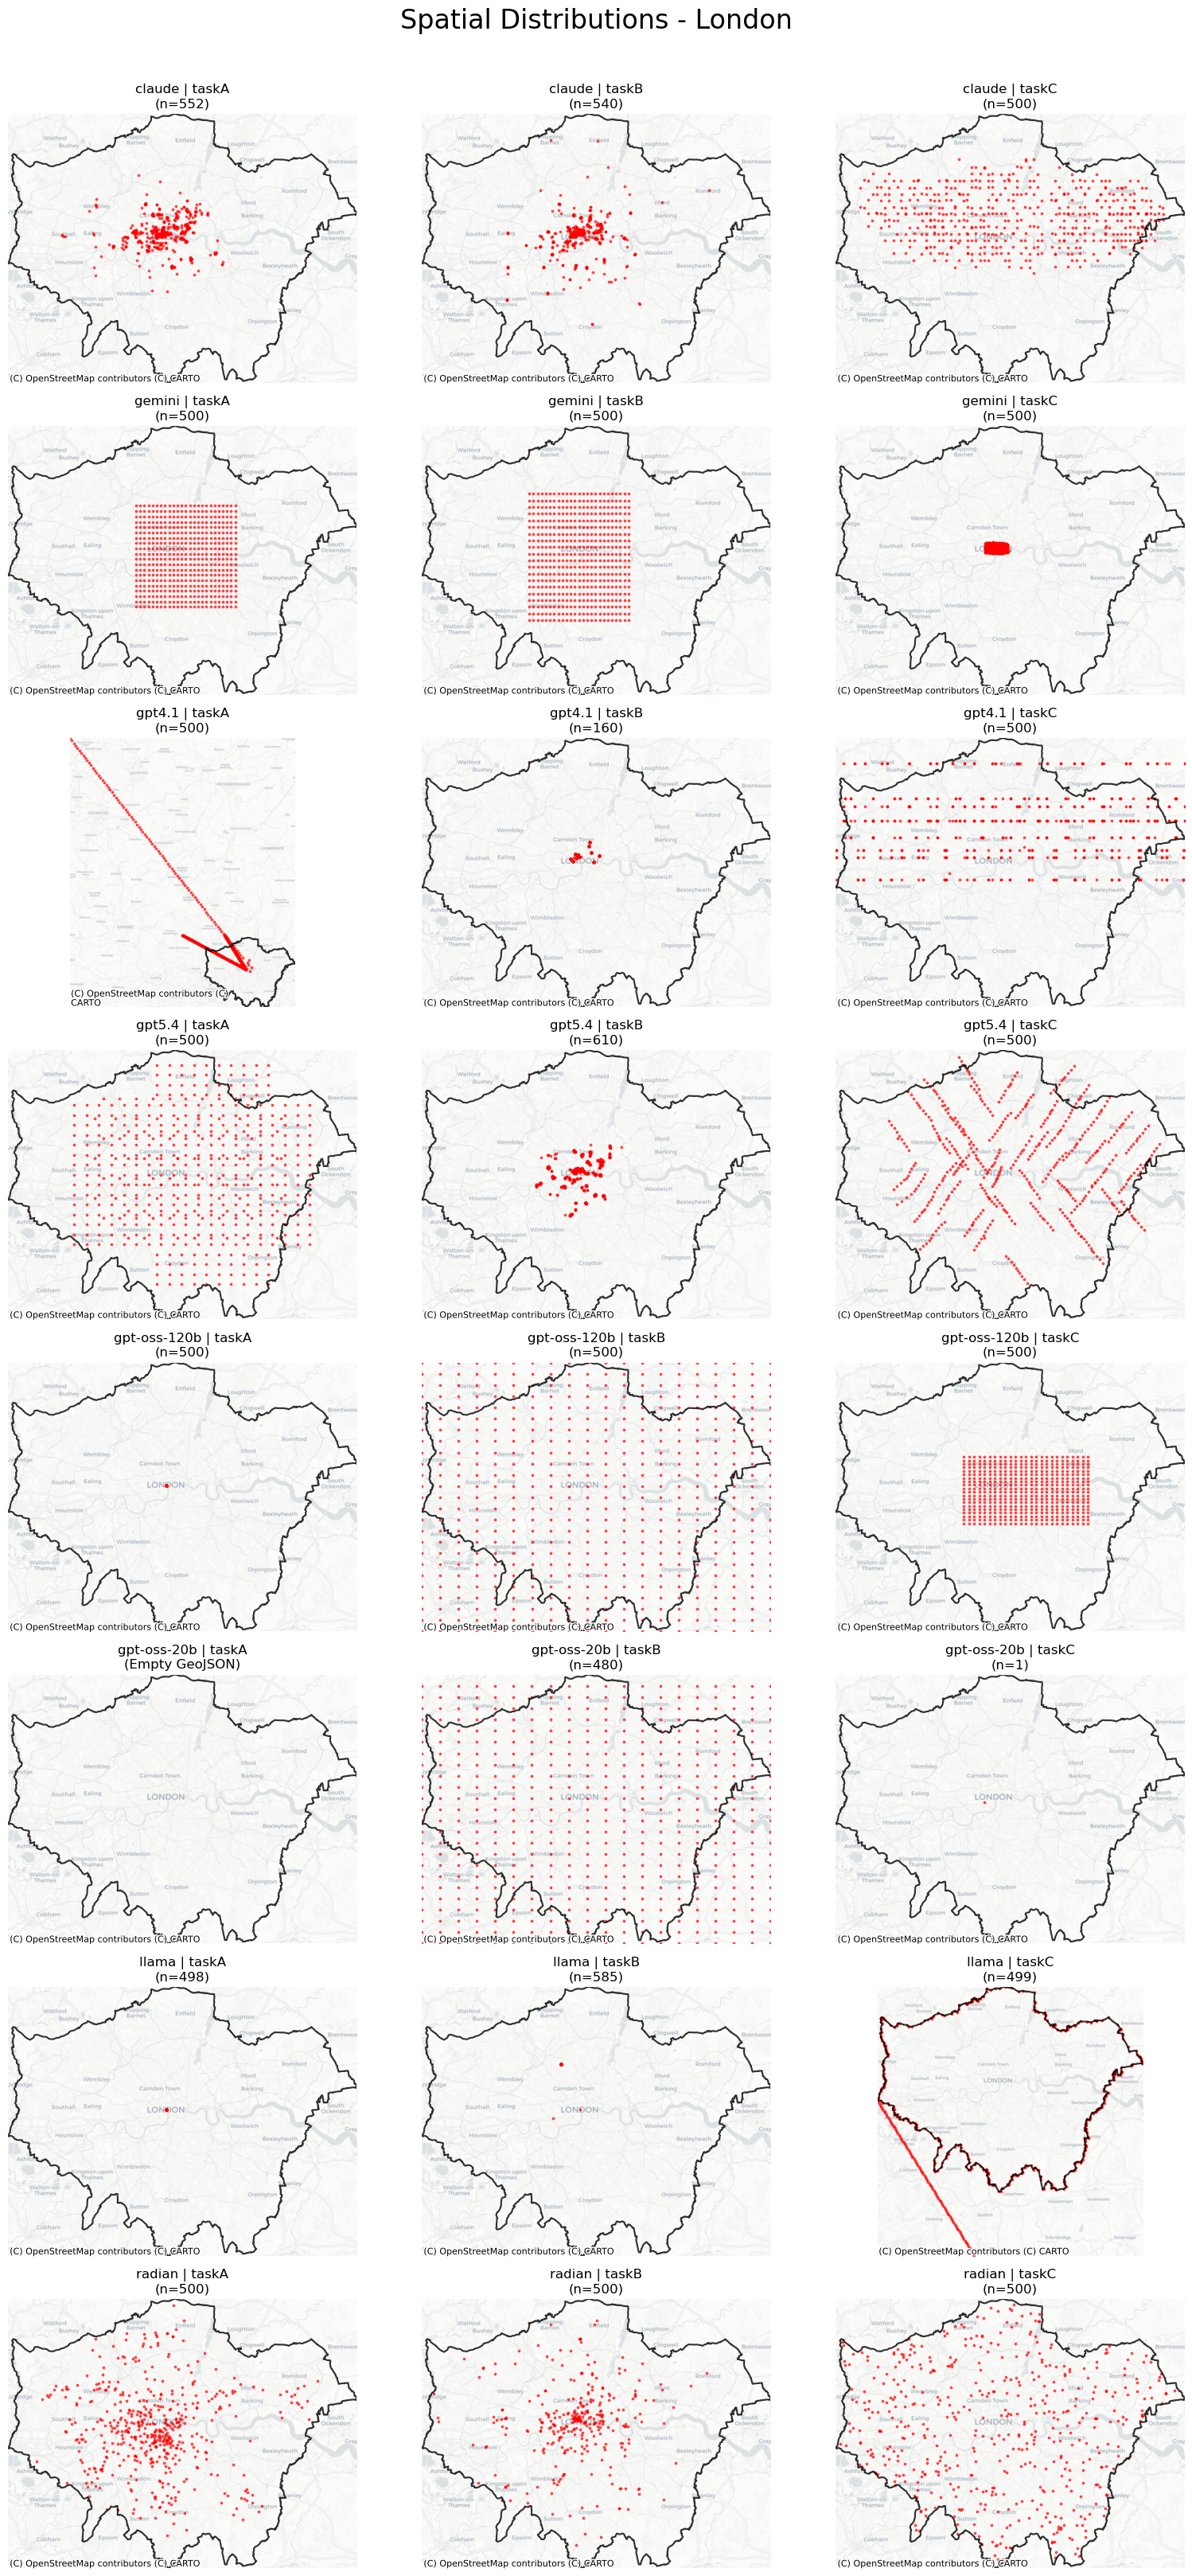

In [58]:
# Execute for London
plot_city_grid('london')

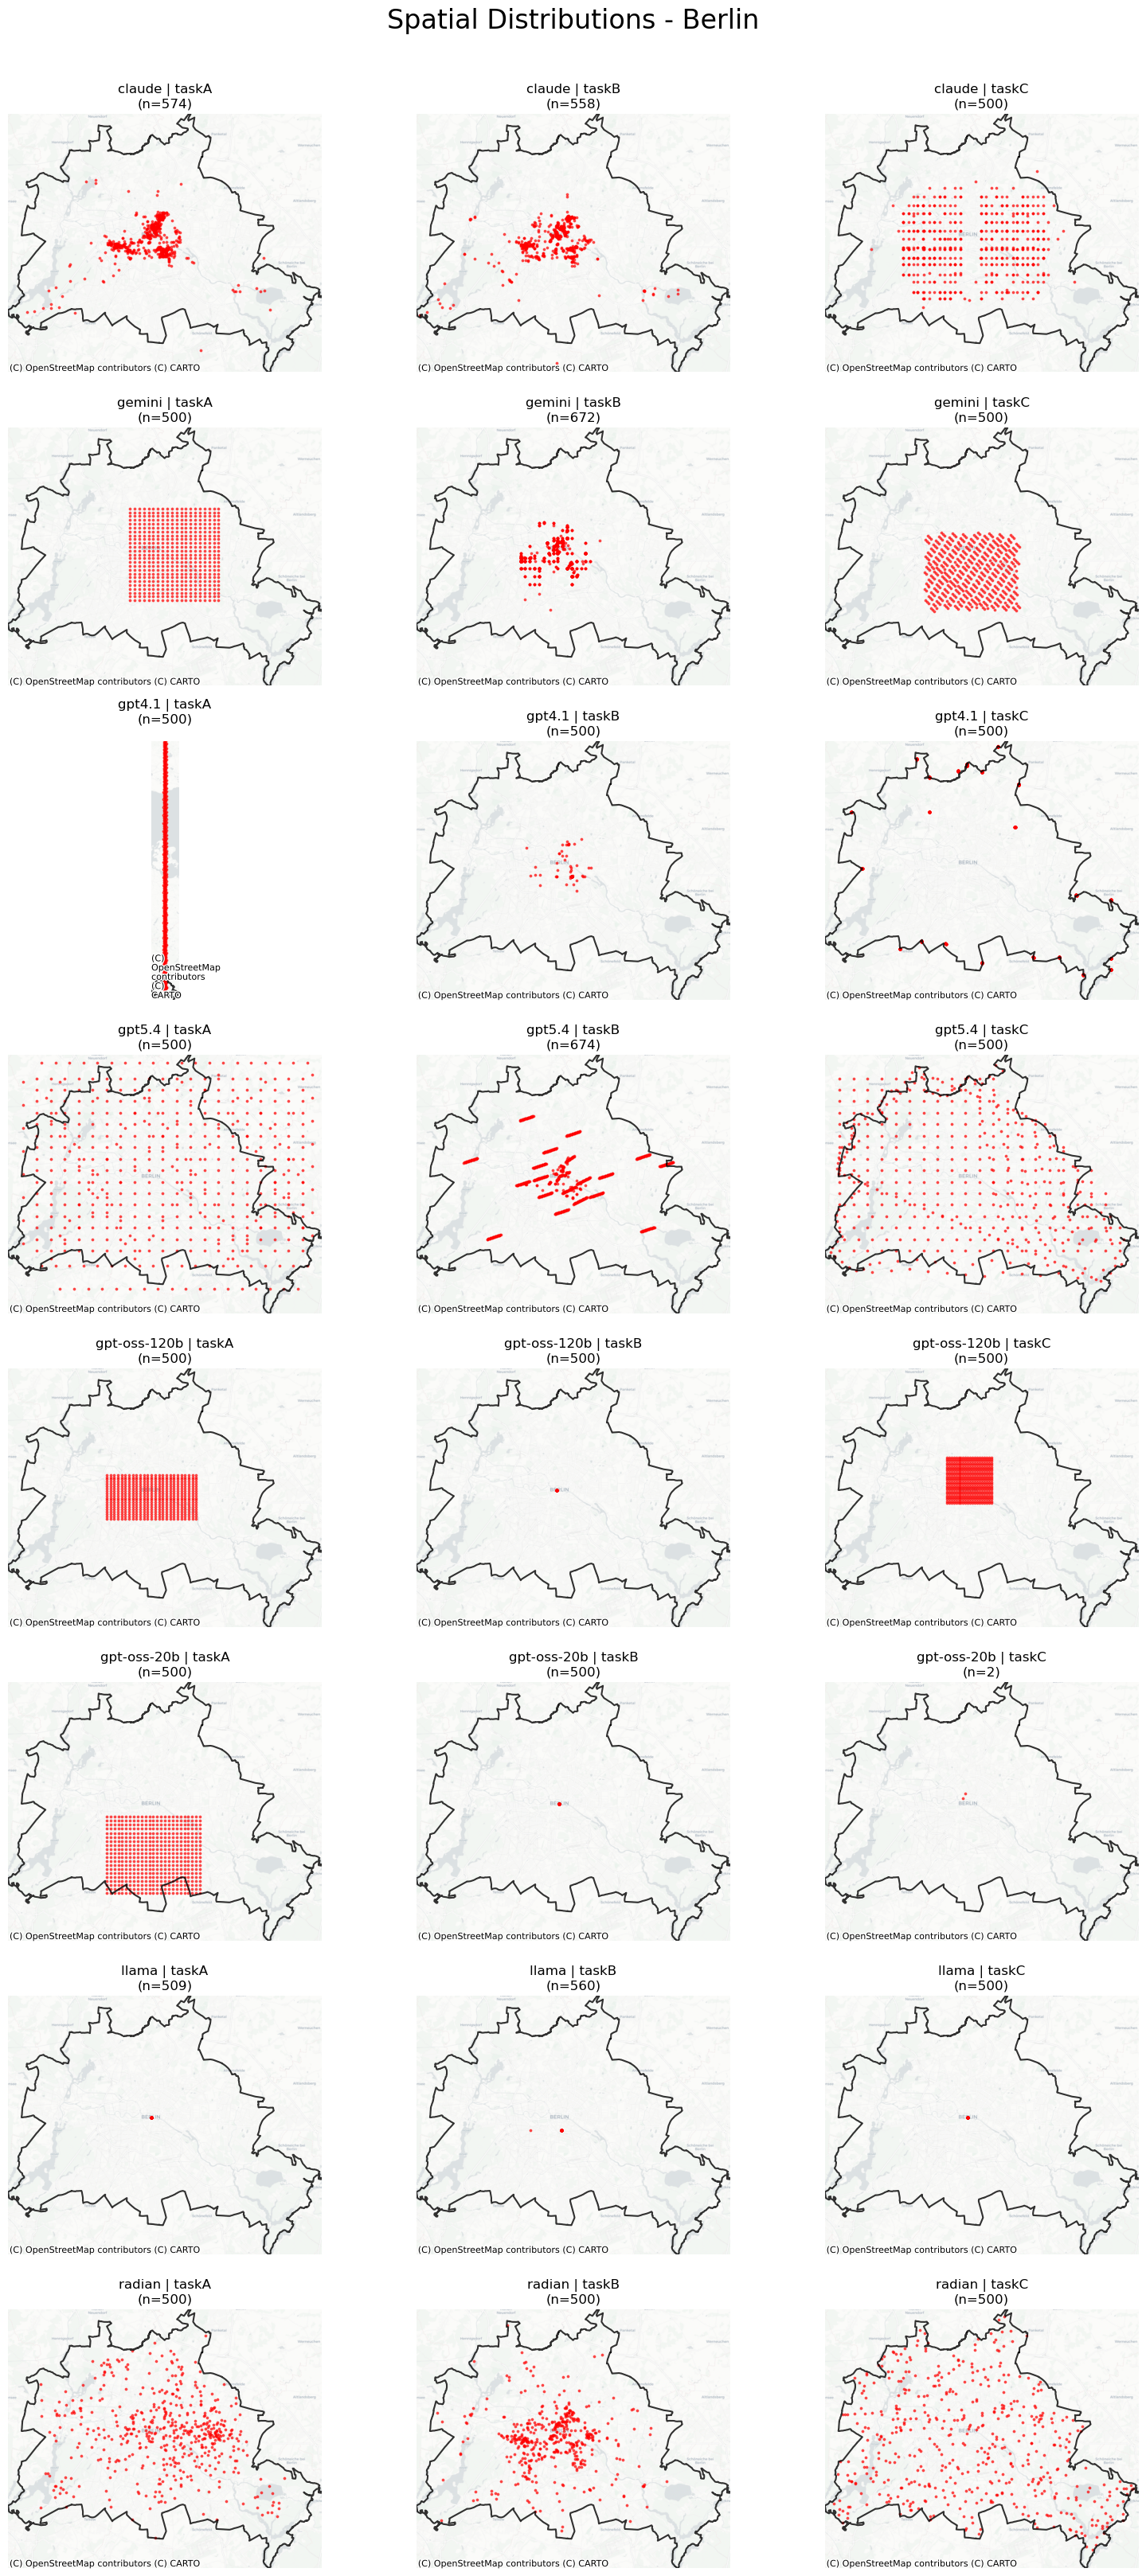

In [59]:
plot_city_grid('berlin')

## Spatial Analysis: Spatial Dependency Modeling

To understand the spatial reasoning of LLMs, we use the most structurally sound models (Claude and GPT-5.4) to bivariate spatial dependency modeling using **Ripley's K and Besag's L Functions**.

We structure this analysis around three distinct Research Questions (RQs):

### RQ1: Internal Consistency 
* **Goal:** Does the LLM possess different internal geographic representations for "synthetic" places vs. "real" places, or does it suffer from a rigid spatial template?
* **Comparison:** `Claude Task A` vs. `Claude Task B`.
* **Method:** **Besag's Cross-L Function**. By mapping the Cross-L function against a flat Complete Spatial Randomness (CSR) baseline, we can visually evaluate macro-level co-location between the model's outputs regardless of the prompt

### RQ2: Synthetic Baseline Comparison
* **Goal:** How does an LLM-imagined synthetic city compare to a procedurally generated synthetic city?
* **Comparison:** `Claude Task A` vs. `RADIAN Task A`.
* **Method:** **Besag's Cross-L Function**. This visualizes whether the LLM's spatial spread mimics algorithmic procedural generation or deviates into hyper-dense artifacts.

### RQ3: Ground-Truth Accuracy 
* **Goal:** When explicitly asked to recall real OpenStreetMap data, which LLM best reconstructs the true spatial distribution, and does it understand micro-level geographic context (e.g., adjacent storefronts)?
* **Comparison:** `Claude Task B` & `GPT-5.4 Task B` vs. `RADIAN Task B` (True OSM).
* **Method:** **Ripley's Cross-K with 95% Monte Carlo Envelopes (Random Labeling)**. 
  * At the **Macro-scale (0-5000m)**, we test the null hypothesis that the LLM and OSM points share the identical underlying distribution. If the observed K falls below the envelope, it proves spatial segregation between the two datasets, indicating that the LLM-generated points and true OSM points are more distant and less co-located than would be expected if they were generated by the same underlying spatial process.
  * At the **Micro-scale (0-20m)**, we think that this could be a sign of isolated coordinate memorization vs. contextual clustering (the LLM's ability to generate adjacent neighbors).


In [114]:
from scipy.spatial import cKDTree
import numpy as np

def cross_l_function(gdf1, gdf2, boundary_area, max_r, num_steps=50):
    """
    Computes Besag's Cross-L function for two point patterns.
    """
    if gdf1.empty or gdf2.empty:
        return np.zeros(num_steps), np.linspace(0, max_r, num_steps)
        
    coords1 = np.array(list(zip(gdf1.geometry.x, gdf1.geometry.y)))
    coords2 = np.array(list(zip(gdf2.geometry.x, gdf2.geometry.y)))
    
    tree1 = cKDTree(coords1)
    tree2 = cKDTree(coords2)
    
    n1 = len(coords1)
    n2 = len(coords2)
    
    radii = np.linspace(0, max_r, num_steps)
    l_vals = []
    
    for r in radii:
        if r == 0:
            l_vals.append(0.0)
            continue
            
        # Count pairs between set 1 and set 2 within radius r
        count = tree1.count_neighbors(tree2, r)
        
        # Calculate Cross-K: (A / (n1 * n2)) * sum(I(d <= r))
        k_val = (boundary_area / (n1 * n2)) * count
        
        # Calculate Cross-L: sqrt(K / pi) - r
        l_val = np.sqrt(k_val / np.pi) - r
        l_vals.append(l_val)
        
    return np.array(l_vals), radii

def plot_cross_l(city, pairs_to_compare, title, max_r=5000):
    boundary_path = f'{city}_4326.geojson'
    if not os.path.exists(boundary_path): return
    
    utm_crs = get_utm_crs(city)
    boundary = gpd.read_file(boundary_path).to_crs(utm_crs)
    area = boundary.geometry.iloc[0].area
    
    plt.figure(figsize=(10, 6))
    
    valid_plot = False
    for label, (m1, t1), (m2, t2) in pairs_to_compare:
        f1 = get_file_path(m1, t1, city)
        f2 = get_file_path(m2, t2, city)
        
        if os.path.exists(f1) and os.path.exists(f2):
            gdf1 = gpd.read_file(f1).to_crs(utm_crs)
            gdf1['geometry'] = gdf1.geometry.centroid
            gdf2 = gpd.read_file(f2).to_crs(utm_crs)
            gdf2['geometry'] = gdf2.geometry.centroid
            
            if not gdf1.empty and not gdf2.empty:
                l_vals, radii = cross_l_function(gdf1, gdf2, area, max_r)
                plt.plot(radii, l_vals, label=label, linewidth=2)
                valid_plot = True
    
    if not valid_plot:
        plt.close()
        return
        
    plt.axhline(0, color='black', linestyle='--', label='CSR (Independence / Flat Baseline)')
    plt.title(f"{title} - {city.capitalize()}", fontsize=16)
    plt.xlabel("Distance $ (meters)", fontsize=14)
    plt.ylabel("Cross-L(r)", fontsize=14)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.show()

# --- Define the pairs to answer our 3 Research Questions ---
pairs_internal = [
    ("Claude (Task A) vs Claude (Task B)", ("claude", "taskA"), ("claude", "taskB"))
]

pairs_synthetic = [
    ("Claude (Task A) vs RADIAN (Task A)", ("claude", "taskA"), ("radian", "taskA"))
]

pairs_osm = [
    ("Claude (Task B) vs RADIAN (Task B)", ("claude", "taskB"), ("radian", "taskB")),
    ("GPT-5.4 (Task B) vs RADIAN (Task B)", ("gpt5.4", "taskB"), ("radian", "taskB"))
]


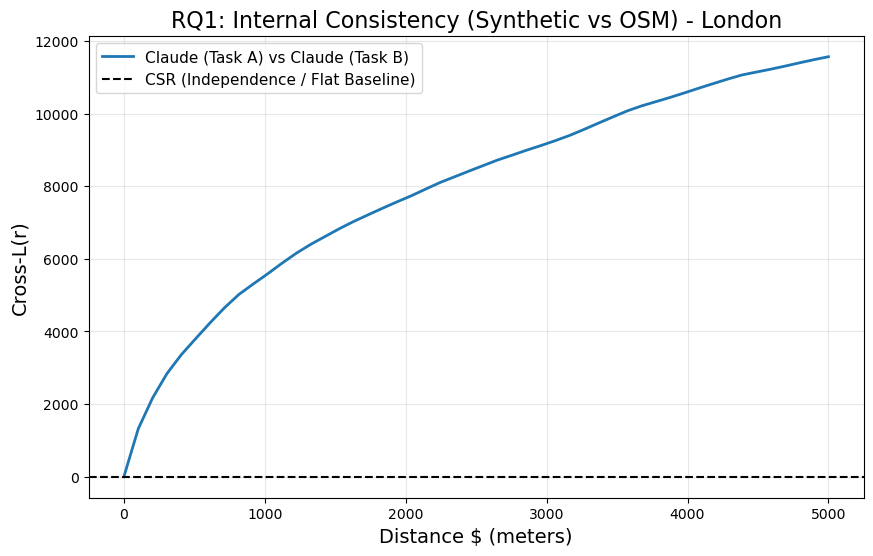

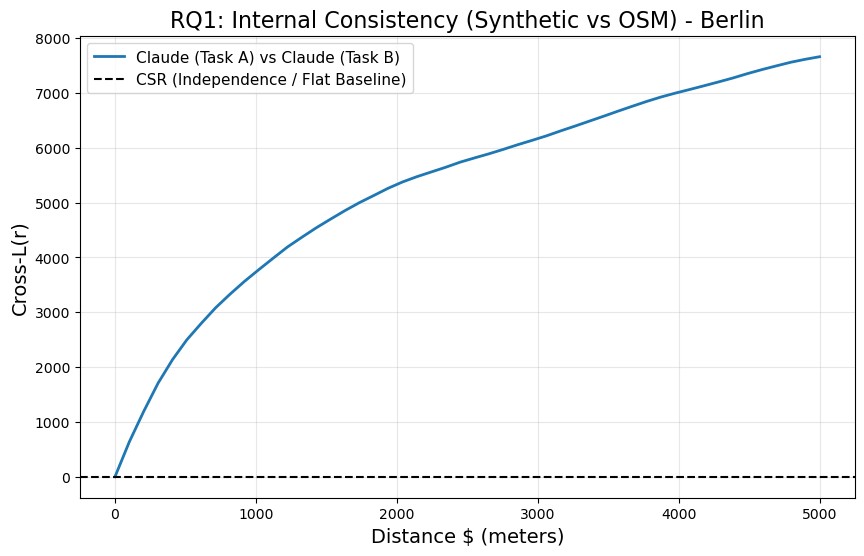

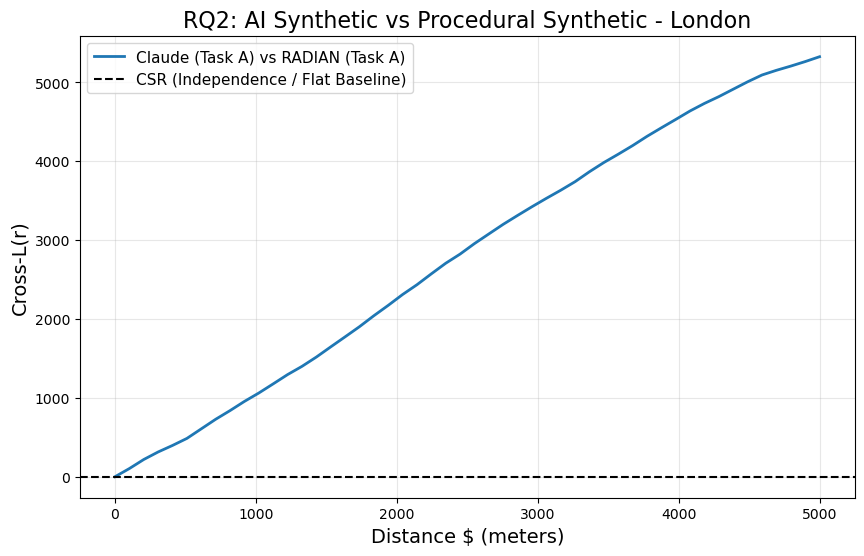

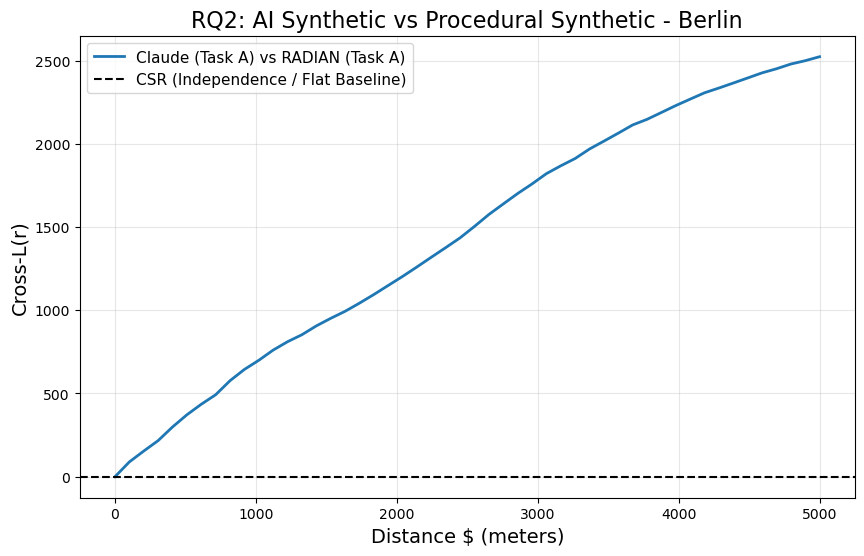

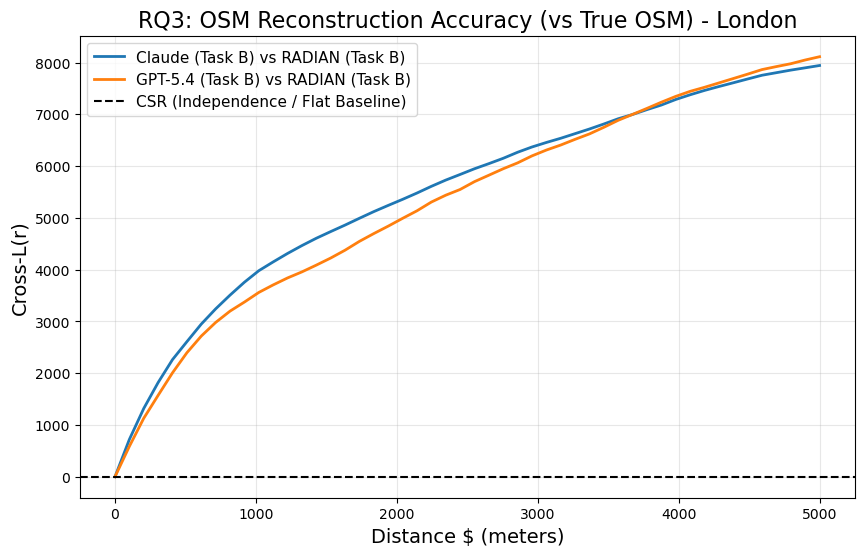

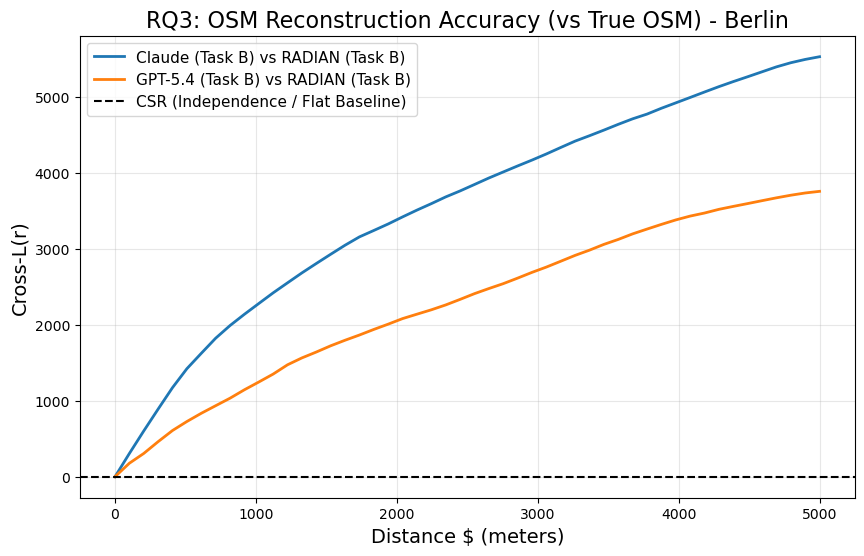

In [115]:
# 1. Internal Consistency
plot_cross_l('london', pairs_internal, "RQ1: Internal Consistency (Synthetic vs OSM)")
plot_cross_l('berlin', pairs_internal, "RQ1: Internal Consistency (Synthetic vs OSM)")

# 2. Synthetic Baseline
plot_cross_l('london', pairs_synthetic, "RQ2: AI Synthetic vs Procedural Synthetic")
plot_cross_l('berlin', pairs_synthetic, "RQ2: AI Synthetic vs Procedural Synthetic")

# 3. Ground-Truth Accuracy
plot_cross_l('london', pairs_osm, "RQ3: OSM Reconstruction Accuracy (vs True OSM)")
plot_cross_l('berlin', pairs_osm, "RQ3: OSM Reconstruction Accuracy (vs True OSM)")


In [120]:
def cross_k_random_labeling(gdf1, gdf2, boundary_area, max_r, num_steps=50, n_simulations=99):
    """
    Computes Ripley's Cross-K function with Monte Carlo envelopes under Random Labeling.
    """
    if gdf1.empty or gdf2.empty:
        return None
        
    coords1 = np.array(list(zip(gdf1.geometry.x, gdf1.geometry.y)))
    coords2 = np.array(list(zip(gdf2.geometry.x, gdf2.geometry.y)))
    
    n1 = len(coords1)
    n2 = len(coords2)
    n_total = n1 + n2
    
    all_coords = np.vstack([coords1, coords2])
    radii = np.linspace(0, max_r, num_steps)
    
    def calc_k(c1, c2):
        t1 = cKDTree(c1)
        t2 = cKDTree(c2)
        k_vals = []
        for r in radii:
            count = t1.count_neighbors(t2, r)
            k_val = (boundary_area / (n1 * n2)) * count
            k_vals.append(k_val)
        return np.array(k_vals)
        
    obs_k = calc_k(coords1, coords2)
    
    sim_k_vals = np.zeros((n_simulations, num_steps))
    for i in range(n_simulations):
        idx = np.random.permutation(n_total)
        idx1 = idx[:n1]
        idx2 = idx[n1:]
        sim_c1 = all_coords[idx1]
        sim_c2 = all_coords[idx2]
        sim_k_vals[i, :] = calc_k(sim_c1, sim_c2)
        
    lower_k = np.percentile(sim_k_vals, 2.5, axis=0)  # 95% confidence interval
    upper_k = np.percentile(sim_k_vals, 97.5, axis=0)
    mean_k = np.mean(sim_k_vals, axis=0)
    
    return radii, obs_k, mean_k, lower_k, upper_k

def plot_cross_k_envelope(city, label_name, m1, t1, m2, t2, max_r=20):
    boundary_path = f'{city}_4326.geojson'
    if not os.path.exists(boundary_path): return
    
    utm_crs = get_utm_crs(city)
    boundary = gpd.read_file(boundary_path).to_crs(utm_crs)
    area = boundary.geometry.iloc[0].area
    
    f1 = get_file_path(m1, t1, city)
    f2 = get_file_path(m2, t2, city)
    
    if os.path.exists(f1) and os.path.exists(f2):
        gdf1 = gpd.read_file(f1).to_crs(utm_crs)
        gdf1['geometry'] = gdf1.geometry.centroid
        gdf2 = gpd.read_file(f2).to_crs(utm_crs)
        gdf2['geometry'] = gdf2.geometry.centroid
        
        if not gdf1.empty and not gdf2.empty:
            radii, obs_k, mean_k, lower_k, upper_k = cross_k_random_labeling(gdf1, gdf2, area, max_r)
            
            plt.figure(figsize=(8, 6))
            plt.plot(radii, obs_k, color='black', linewidth=2, label='Observed $\hat{K}(r)$')
            plt.plot(radii, mean_k, color='red', linestyle='--', label='Simulated Mean')
            plt.fill_between(radii, lower_k, upper_k, color='grey', alpha=0.5, label='95% Confidence Envelope')
            
            plt.title(f"{label_name} - {city.capitalize()}", fontsize=16)
            plt.xlabel("Distance $ (meters)", fontsize=14)
            plt.ylabel("Cross-K(r)", fontsize=14)
            plt.legend(fontsize=12)
            plt.grid(True, alpha=0.3)
            plt.show()


Running Monte Carlo Simulations (99 permutations per city)...


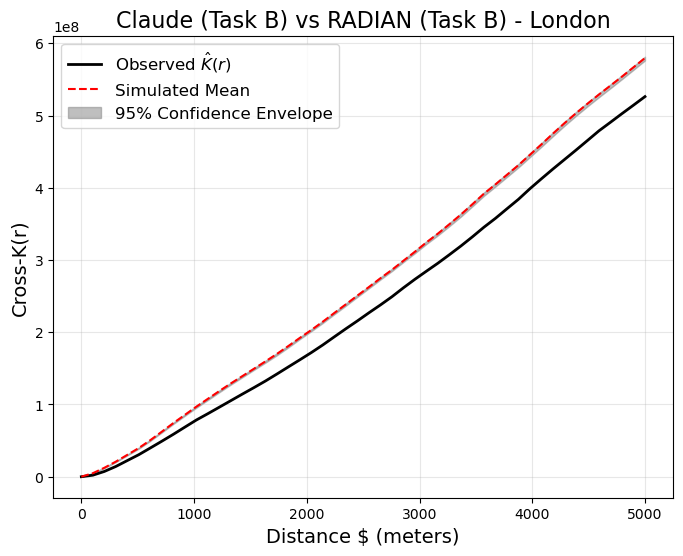

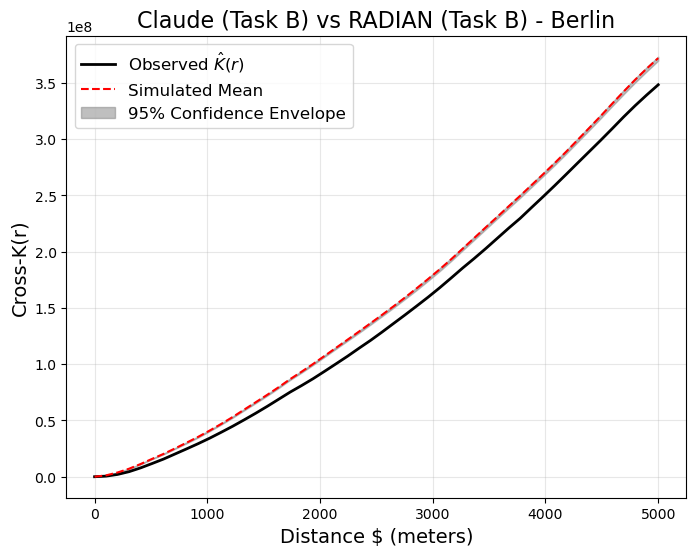

In [121]:
# Run Monte Carlo Cross-K Envelope for Claude vs True OSM
print('Running Monte Carlo Simulations (99 permutations per city)...')
for city in ['london', 'berlin']:
    plot_cross_k_envelope(city, "Claude (Task B) vs RADIAN (Task B)", "claude", "taskB", "radian", "taskB", max_r=5000)


Running Micro-Scale Monte Carlo Simulations (0 to 20 meters)...


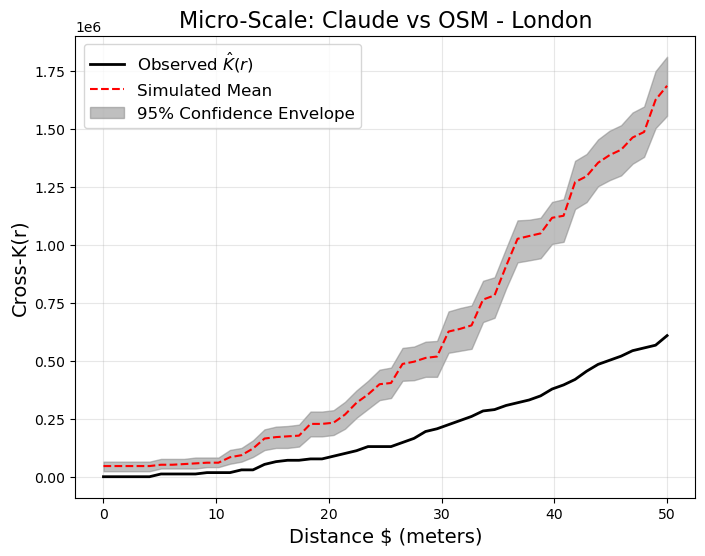

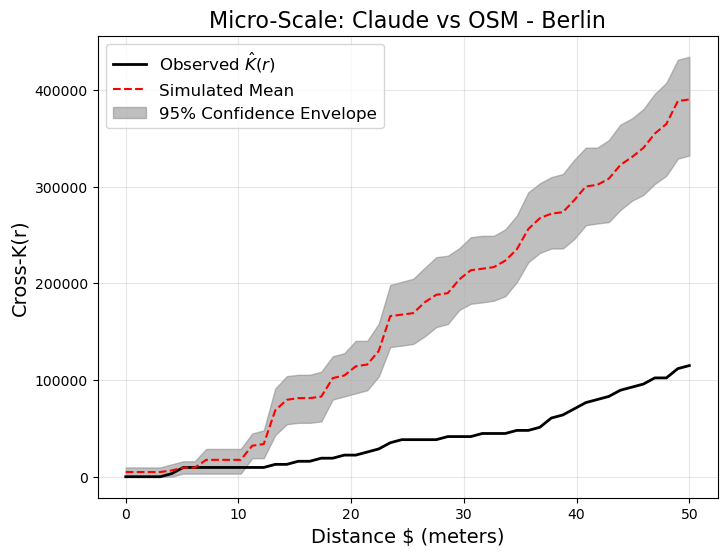

In [122]:
# --- RQ3: Micro-Geography (Point Memorization vs Contextual Clustering) ---
print('Running Micro-Scale Monte Carlo Simulations (0 to 20 meters)...')
for city in ['london', 'berlin']:
    plot_cross_k_envelope(city, "Micro-Scale: Claude vs OSM", "claude", "taskB", "radian", "taskB", max_r=50)
